# 0. MitoCheck Dataset: Exploratory Data Analysis

## Overview
This notebook performs an exploratory data analysis (EDA) of the [MitoCheck](https://www.mitocheck.org/) single-cell morphology dataset.
The MitoCheck project systematically knocked down ~21,000 human genes via siRNA and classified the resulting cell phenotypes using time-lapse microscopy.
Each cell in this dataset is assigned a **phenotypic class** (e.g., "Mitosis", "Apoptosis", "Shape") based on its observed morphology after gene knockdown.

We use this dataset as a benchmark for the **buscar** compound-prioritization pipeline, since it provides ground-truth phenotypic labels that let us evaluate whether morphological signatures capture biologically meaningful variation.

**Sections in this notebook:**
1. **Setup** — Imports, paths, and configuration loading
2. **Data Loading & Cleaning** — Read profiles, remove QC failures, standardize control labels
3. **Dataset Overview** — Dimensions, feature space, and unique genes/classes
4. **Phenotypic Class Distribution** — Cell counts per class and control vs. treatment breakdown
5. **Gene-Level Phenotype Composition** — Per-gene phenotype proportions and cell-count distributions
6. **Data Quality Checks** — Missing values, duplicate rows
7. **Feature Correlations** — Identify redundant features via correlation clustermap

In [1]:
import sys
import pathlib
import itertools

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# allow imports from the project root (e.g., utils/ and buscar/)
sys.path.append("../../")
from utils.io_utils import load_profiles, load_configs

## 1. Setup: Input & Output Paths
Define all file paths for input data, configuration files, and output directories.
All results (tables, plots) are saved under `results/eda/` to keep EDA outputs separate from downstream analysis artifacts.

In [3]:
# ---------------------
# Input paths
# ---------------------
# Root directory containing downloaded single-cell morphology profiles
data_dir = pathlib.Path("../0.download-data/data/sc-profiles/").resolve(strict=True)
mitocheck_data = (data_dir / "mitocheck").resolve(strict=True)

# Concatenated MitoCheck single-cell profiles (one row per cell)
mitocheck_profile_path = (mitocheck_data / "mitocheck_concat_profiles.parquet").resolve(
    strict=True
)

# ENSG → gene-symbol mapping (MitoCheck uses Ensembl gene IDs internally)
# ensg_genes_config_path = (
#     mitocheck_data / "mitocheck_ensg_to_gene_symbol_mapping.json"
# ).resolve(strict=True)

# Feature-space config: defines which columns are metadata vs. morphology features
mitocheck_feature_space_config = (
    mitocheck_data / "mitocheck_feature_space_configs.json"
).resolve(strict=True)

# ---------------------
# Output paths
# ---------------------
# All EDA outputs (CSV tables + plots) are stored under results/eda/
results_dir = pathlib.Path("results/").resolve()
results_dir.mkdir(exist_ok=True)

eda_results_dir = (results_dir / "eda").resolve()
eda_results_dir.mkdir(exist_ok=True)

plots_dir = (eda_results_dir / "plots/").resolve()
plots_dir.mkdir(exist_ok=True)

## 2. Data Loading & Cleaning
Load the concatenated MitoCheck profiles and apply two cleaning steps:
1. **Remove QC failures** — Rows where `Metadata_Gene == "failed QC"` did not pass upstream quality control and are excluded.
2. **Standardize control labels** — Rename `"negative control"` → `"negcon"` and `"positive control"` → `"poscon"` so control labels are consistent with the buscar pipeline conventions.

In [5]:
# Load configuration files:
#   - ensg_genes_decoder: maps Ensembl gene IDs (ENSG*) to human-readable gene symbols
#   - feature_space_configs: lists metadata columns vs. morphology feature columns
# ensg_genes_decoder = load_configs(ensg_genes_config_path)
feature_space_configs = load_configs(mitocheck_feature_space_config)

In [6]:
# Load the parquet file into a Polars DataFrame (one row = one single cell)
mitocheck_df = load_profiles(mitocheck_profile_path)

# Remove rows that failed upstream QC — these cells have unreliable measurements
mitocheck_df = mitocheck_df.filter(pl.col("Metadata_Gene") != "failed QC")

# Standardize control labels to match buscar pipeline conventions:
#   "negative control" → "negcon"  (untreated / non-targeting siRNA)
#   "positive control" → "poscon"  (known phenotype-inducing siRNA)
mitocheck_df = mitocheck_df.with_columns(
    pl.col("Metadata_Gene").map_elements(
        lambda x: (
            "negcon"
            if x == "negative control"
            else ("poscon" if x == "positive control" else x)
        ),
        return_dtype=pl.String,
    )
)

print(f"Loaded profiles shape: {mitocheck_df.shape}")
mitocheck_df.head()

Loaded profiles shape: (1394555, 172)


Metadata_cell_id,index,Mitocheck_Phenotypic_Class,Cell_UUID,Location_Center_X,Location_Center_Y,Metadata_Plate,Metadata_Well,Metadata_Frame,Metadata_Site,Metadata_Plate_Map_Name,Metadata_DNA,Metadata_Gene,Metadata_Gene_Replicate,AreaShape_Zernike_5_1,AreaShape_Zernike_6_6,Texture_Variance_DNA_3_03_256,Intensity_MeanIntensity_DNA,AreaShape_Zernike_8_6,Texture_DifferenceEntropy_DNA_3_00_256,AreaShape_ConvexArea,Texture_DifferenceEntropy_DNA_3_02_256,Intensity_MassDisplacement_DNA,Texture_SumVariance_DNA_3_03_256,AreaShape_Extent,RadialDistribution_MeanFrac_DNA_1of4,RadialDistribution_MeanFrac_DNA_2of4,Granularity_16_DNA,AreaShape_MedianRadius,RadialDistribution_MeanFrac_DNA_4of4,RadialDistribution_RadialCV_DNA_3of4,Texture_InverseDifferenceMoment_DNA_3_01_256,Texture_InverseDifferenceMoment_DNA_3_02_256,Texture_Contrast_DNA_3_03_256,AreaShape_MinorAxisLength,AreaShape_FormFactor,AreaShape_MajorAxisLength,…,Texture_Correlation_DNA_3_03_256,Granularity_11_DNA,Texture_InfoMeas1_DNA_3_03_256,Granularity_8_DNA,RadialDistribution_MeanFrac_DNA_3of4,AreaShape_Zernike_8_4,AreaShape_Zernike_7_5,Texture_Entropy_DNA_3_02_256,Texture_SumEntropy_DNA_3_00_256,Texture_InfoMeas1_DNA_3_00_256,Texture_AngularSecondMoment_DNA_3_02_256,Intensity_StdIntensityEdge_DNA,RadialDistribution_RadialCV_DNA_4of4,AreaShape_Zernike_9_9,AreaShape_Compactness,Granularity_3_DNA,RadialDistribution_FracAtD_DNA_1of4,Granularity_1_DNA,AreaShape_Zernike_2_0,Texture_Contrast_DNA_3_01_256,AreaShape_Zernike_0_0,Texture_InfoMeas1_DNA_3_01_256,Texture_SumVariance_DNA_3_02_256,Granularity_10_DNA,Texture_SumAverage_DNA_3_02_256,Texture_Correlation_DNA_3_00_256,AreaShape_Zernike_8_0,Texture_AngularSecondMoment_DNA_3_01_256,Granularity_13_DNA,Neighbors_PercentTouching_Adjacent,Granularity_9_DNA,Intensity_MADIntensity_DNA,Texture_DifferenceVariance_DNA_3_02_256,Granularity_6_DNA,AreaShape_Center_X,Texture_Variance_DNA_3_00_256,Texture_DifferenceVariance_DNA_3_01_256
str,u32,str,str,i64,i64,str,i64,i64,i64,str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""9c70a4df94a3ad6cfb58d19a11a2a5…",0,"""Large""","""21da27ab-873a-41f4-ab98-49170c…",397,618,"""LT0010_27""",173,83,1,"""LT0010_27_173""","""LT0010_27/LT0010_27_173_83.tif""","""RAB21""",1,-0.926224,-0.799771,-0.321772,-0.068867,1.232027,0.035521,2.503212,-0.210412,-0.878776,-0.323494,0.521839,0.076917,-0.441865,-0.01598,1.643822,0.698414,-0.787404,-0.344711,-0.069676,-0.278961,1.170372,-0.679105,2.813648,…,0.713151,-0.031146,0.587211,-0.096468,-0.666539,0.569697,-0.433315,0.513607,0.186885,0.570163,-0.347817,-0.226037,-0.475582,0.459925,0.438754,-1.022403,-0.804871,-0.524722,1.180296,-0.283944,-1.038763,0.534493,-0.311945,-0.046809,-0.121025,0.28992,-1.109334,-0.340446,-0.025113,-0.39273,-0.067376,-0.408029,-0.358357,0.821603,-0.705193,-0.322818,-0.364455
"""4169f8227be122502cf3940816d5cc…",1,"""Large""","""82f7949b-4ea2-45c8-8dd9-7854ca…",359,584,"""LT0010_27""",173,83,1,"""LT0010_27_173""","""LT0010_27/LT0010_27_173_83.tif""","""RAB21""",1,-0.513065,-1.352548,-0.242154,0.384775,-0.366503,0.265328,3.444921,0.216337,0.361058,-0.207762,-1.057268,-0.768623,-0.593857,-0.01598,2.263011,0.827009,0.05206,-0.497082,-0.471068,-0.265307,2.14545,-0.147518,2.988465,…,1.783401,-0.031146,0.284336,-0.096468,-0.470631,-0.425917,0.451034,0.876355,0.475488,0.429172,-0.381903,-0.204892,-0.520637,0.233967,0.044005,-1.782799,-0.80057,-0.392471,0.8452,-0.227807,-0.402259,0.416687,-0.243026,-0.046809,0.316861,0.664302,0.635363,-0.364557,-0.025113,-0.39273,-0.067376,-0.19735,-0.426788,2.16752,-0.804212,-0.250865,-0.40566
"""c29f04284ea6a9bc25bb5792e95fce…",2,"""Large""","""cec7234f-fe35-4411-aded-f8112b…",383,685,"""LT0010_27""",173,83,1,"""LT0010_27_173""","""LT0010_27/LT0010_27_173_83.tif""","""RAB21""",1,-0.293436,-0.650008,-0.221919,0.471951

## 3. Dataset Overview
Summarize the dataset dimensions: total cells, number of metadata vs. morphology columns, unique genes tested, and unique phenotypic classes.
This gives a high-level sense of the dataset's size and complexity before diving deeper.

In [7]:
# Split columns into metadata (annotations) and morphology (numeric features)
meta_cols = [
    c
    for c in mitocheck_df.columns
    if c.startswith("Metadata_") or c in feature_space_configs["metadata-features"]
]
morph_cols = [c for c in mitocheck_df.columns if c not in meta_cols]

# Compute high-level dataset statistics
n_cells, n_total_cols = mitocheck_df.shape
n_genes = mitocheck_df.filter(~pl.col("Metadata_Gene").is_in(["negcon", "poscon"]))[
    "Metadata_Gene"
].n_unique()
n_phenotypes = mitocheck_df["Mitocheck_Phenotypic_Class"].n_unique()

print(f"Total cells (rows):            {n_cells:,}")
print(f"Total columns:                 {n_total_cols}")
print(f"  - Metadata columns:          {len(meta_cols)}")
print(f"  - Morphology features:       {len(morph_cols)}")
print(f"Unique genes (excl. controls): {n_genes}")
print(f"Unique phenotypic classes:     {n_phenotypes}")
print(
    f"\nPhenotypic classes: {sorted(mitocheck_df['Mitocheck_Phenotypic_Class'].unique().to_list())}"
)

Total cells (rows):            1,394,555
Total columns:                 172
  - Metadata columns:          14
  - Morphology features:       158
Unique genes (excl. controls): 62
Unique phenotypic classes:     18

Phenotypic classes: ['ADCCM', 'Anaphase', 'Apoptosis', 'Binuclear', 'Elongated', 'Folded', 'Grape', 'Hole', 'Interphase', 'Large', 'Metaphase', 'MetaphaseAlignment', 'OutOfFocus', 'Polylobed', 'Prometaphase', 'SmallIrregular', 'negcon', 'poscon']


## 4. Phenotypic Class Distribution

### 4a. Control vs. Treatment Breakdown
Count how many cells belong to negative controls (`negcon`), positive controls (`poscon`), and gene-knockdown treatments.
This breakdown is important because downstream buscar analysis compares treatment signatures against the negative-control distribution.

In [8]:
# Separate cells into control groups and gene-knockdown treatments
negcon_df = mitocheck_df.filter(pl.col("Mitocheck_Phenotypic_Class") == "negcon")
poscon_df = mitocheck_df.filter(pl.col("Mitocheck_Phenotypic_Class") == "poscon")
treatment_df = mitocheck_df.filter(
    ~pl.col("Mitocheck_Phenotypic_Class").is_in(["negcon", "poscon"])
)

print(f"Negative control cells: {negcon_df.shape[0]:,}")
print(f"Positive control cells: {poscon_df.shape[0]:,}")
print(f"  - Positive control genes: {poscon_df['Metadata_Gene'].unique().to_list()}")
print(f"Treatment cells:        {treatment_df.shape[0]:,}")

Negative control cells: 779,993
Positive control cells: 612,059
  - Positive control genes: ['KIF11', 'COPB', 'ENSG00000149503']
Treatment cells:        2,503


### 4b. Cell Counts per Phenotypic Class
Visualize how many treatment cells fall into each MitoCheck phenotypic class.
A log-scale y-axis is used because some classes (e.g., "Shape") dominate while others are very rare — understanding this imbalance is critical for interpreting downstream results.

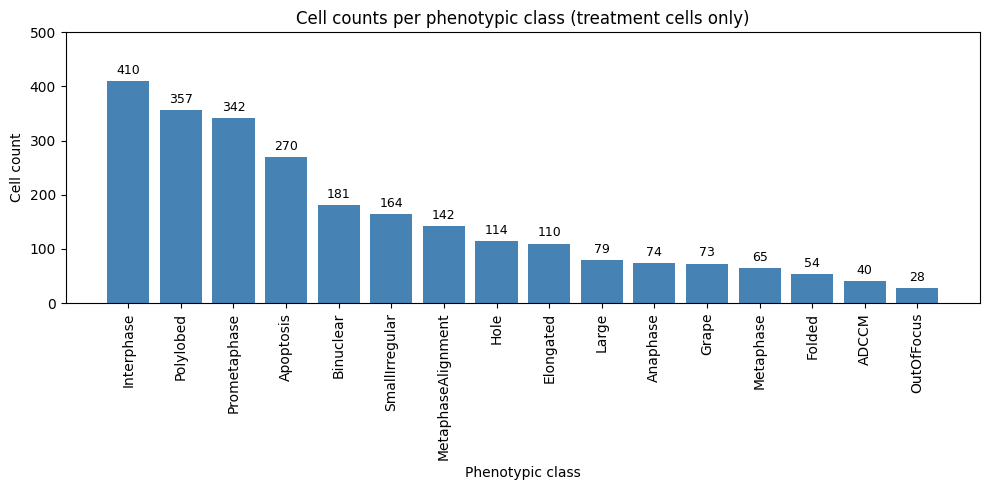

In [10]:
# Count cells per phenotypic class (excluding controls)
cell_counts = (
    treatment_df["Mitocheck_Phenotypic_Class"]
    .value_counts()
    .sort("count", descending=True)
)

# Bar plot with linear y-axis to visualize class imbalance
cell_counts_pd = cell_counts.to_pandas()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    cell_counts_pd["Mitocheck_Phenotypic_Class"],
    cell_counts_pd["count"],
    color="steelblue",
)
ax.set_title("Cell counts per phenotypic class (treatment cells only)")
ax.set_xlabel("Phenotypic class")
ax.set_ylabel("Cell count")
# Set y-axis limit to 500
ax.set_ylim(0, 500)
# Add the number of cells on top of each bar
for bar, count in zip(bars, cell_counts_pd["count"]):
    height = bar.get_height()
    ax.annotate(
        f"{int(count):,}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black",
    )
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(plots_dir / "phenotypic_class_distribution.png", dpi=300)
plt.show()

In [ ]:
# Persist the cell-count table for reference in later notebooks
cell_counts.write_csv(eda_results_dir / "cell_counts_per_phenotypic_class.csv")

# Display the full table
cell_counts

Mitocheck_Phenotypic_Class,count
str,u32
"""Interphase""",410
"""Polylobed""",357
"""Prometaphase""",342
"""Apoptosis""",270
"""Binuclear""",181
…,…
"""Grape""",73
"""Metaphase""",65
"""Folded""",54


## 5. Gene-Level Phenotype Composition

For each gene knockdown, what proportion of its cells belong to each phenotypic class?
A gene whose cells are dominated by a single class has a "pure" phenotype, whereas a gene with a roughly uniform distribution across many classes may have a weak or noisy phenotypic effect.
This per-gene breakdown helps us understand phenotype purity and will inform how we aggregate signatures in downstream buscar analysis.

In [ ]:
# For each gene, compute the proportion of cells in every phenotypic class.
# Steps:
#   1. Group by (gene, phenotypic class) and count cells
#   2. Compute total cells per gene using a window function
#   3. Derive proportion = count / total_count
phenotype_proportions = (
    treatment_df.group_by(["Metadata_Gene", "Mitocheck_Phenotypic_Class"])
    .agg(pl.len().alias("count"))
    .with_columns(pl.col("count").sum().over("Metadata_Gene").alias("total_count"))
    .with_columns((pl.col("count") / pl.col("total_count")).alias("proportion"))
    .select(
        [
            "Metadata_Gene",
            "Mitocheck_Phenotypic_Class",
            "count",
            "total_count",
            "proportion",
        ]
    )
    .sort(["Metadata_Gene", "proportion"], descending=[False, True])
)

# Save the full table for downstream use
phenotype_proportions.write_csv(eda_results_dir / "phenotype_proportions_per_gene.csv")

# Preview the first few rows
phenotype_proportions.head()

Metadata_Gene,Mitocheck_Phenotypic_Class,count,total_count,proportion
str,str,u32,u32,f64
"""ABCB8""","""OutOfFocus""",18,18,1.0
"""ANLN""","""Polylobed""",17,34,0.5
"""ANLN""","""Binuclear""",16,34,0.470588
"""ANLN""","""MetaphaseAlignment""",1,34,0.029412
"""AVPR2""","""MetaphaseAlignment""",5,5,1.0


In [ ]:
# Spot-check: inspect phenotype composition for a single gene (PAPPA)
# to verify the table looks reasonable and proportions sum to 1.0
phenotype_proportions.filter(pl.col("Metadata_Gene") == "PAPPA")

Metadata_Gene,Mitocheck_Phenotypic_Class,count,total_count,proportion
str,str,u32,u32,f64
"""PAPPA""","""Prometaphase""",30,34,0.882353
"""PAPPA""","""Metaphase""",2,34,0.058824
"""PAPPA""","""Apoptosis""",2,34,0.058824


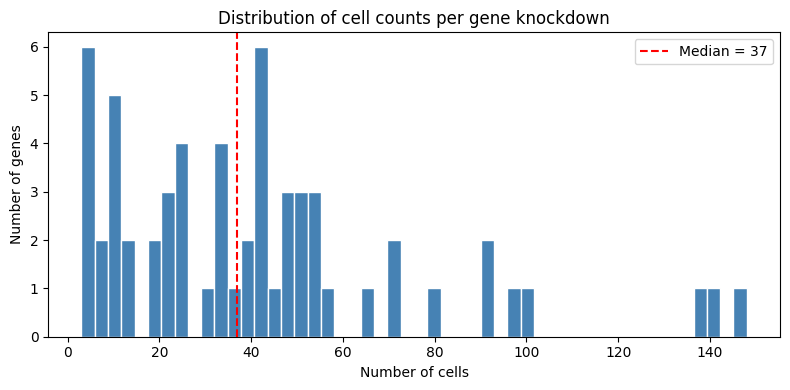

In [ ]:
# How many cells does each gene knockdown contribute?
# Genes with very few cells may produce unreliable signatures.
cells_per_gene = (
    treatment_df.group_by("Metadata_Gene")
    .agg(pl.len().alias("n_cells"))
    .sort("n_cells", descending=True)
)

# Histogram of cells-per-gene with a median reference line
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    cells_per_gene["n_cells"].to_list(), bins=50, color="steelblue", edgecolor="white"
)
ax.set_title("Distribution of cell counts per gene knockdown")
ax.set_xlabel("Number of cells")
ax.set_ylabel("Number of genes")
median_val = cells_per_gene["n_cells"].median()
ax.axvline(median_val, color="red", linestyle="--", label=f"Median = {median_val:.0f}")
ax.legend()
plt.tight_layout()
plt.savefig(plots_dir / "cells_per_gene_distribution.png", dpi=150)
plt.show()

## 6. Data Quality Checks
Before using this data in downstream analyses, verify it is free from common quality issues:
missing/null values and duplicate rows. Problems here could silently bias morphological signatures.

### 6a. Missing Values
Check every column for null entries. Missing morphology features could distort mean/median signatures,
and missing metadata would break downstream grouping operations.

In [ ]:
# Count null values in every column and report any that are non-zero
null_counts = mitocheck_df.null_count()
cols_with_nulls = {
    col: null_counts[col][0] for col in null_counts.columns if null_counts[col][0] > 0
}

if cols_with_nulls:
    print(f"Columns with missing values ({len(cols_with_nulls)}):")
    for col, cnt in sorted(cols_with_nulls.items(), key=lambda x: -x[1]):
        pct = cnt / mitocheck_df.shape[0] * 100
        print(f"  {col}: {cnt:,} ({pct:.2f}%)")
else:
    print("No missing values found in any column.")

No missing values found in any column.


### 6b. Duplicate Rows
Each cell should have a unique `Cell_UUID`. Duplicates would inflate sample sizes and distort aggregate statistics.

In [ ]:
# Verify that every cell has a unique identifier (no duplicate rows)
if "Cell_UUID" in mitocheck_df.columns:
    n_unique_uuids = mitocheck_df["Cell_UUID"].n_unique()
    n_total = mitocheck_df.shape[0]
    n_dupes = n_total - n_unique_uuids
    print(f"Total rows:        {n_total:,}")
    print(f"Unique Cell_UUIDs: {n_unique_uuids:,}")
    print(f"Duplicate UUIDs:   {n_dupes:,}")
else:
    print("No Cell_UUID column found; skipping duplicate check.")

Total rows:        1,394,555
Unique Cell_UUIDs: 1,394,555
Duplicate UUIDs:   0


## 7. Feature Correlations
Highly correlated features carry redundant information and can inflate variance in downstream analyses (e.g., PCA, signature generation).
We compute the full pairwise Pearson correlation matrix across all morphology features and visualize it as a **clustermap** (with Ward hierarchical clustering on both axes) to reveal groups of co-varying features.

We also count the number of feature pairs with |r| > 0.9 as a rough measure of redundancy.

/home/erikserrano/Software/miniconda3/envs/buscar/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/erikserrano/Software/miniconda3/envs/buscar/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


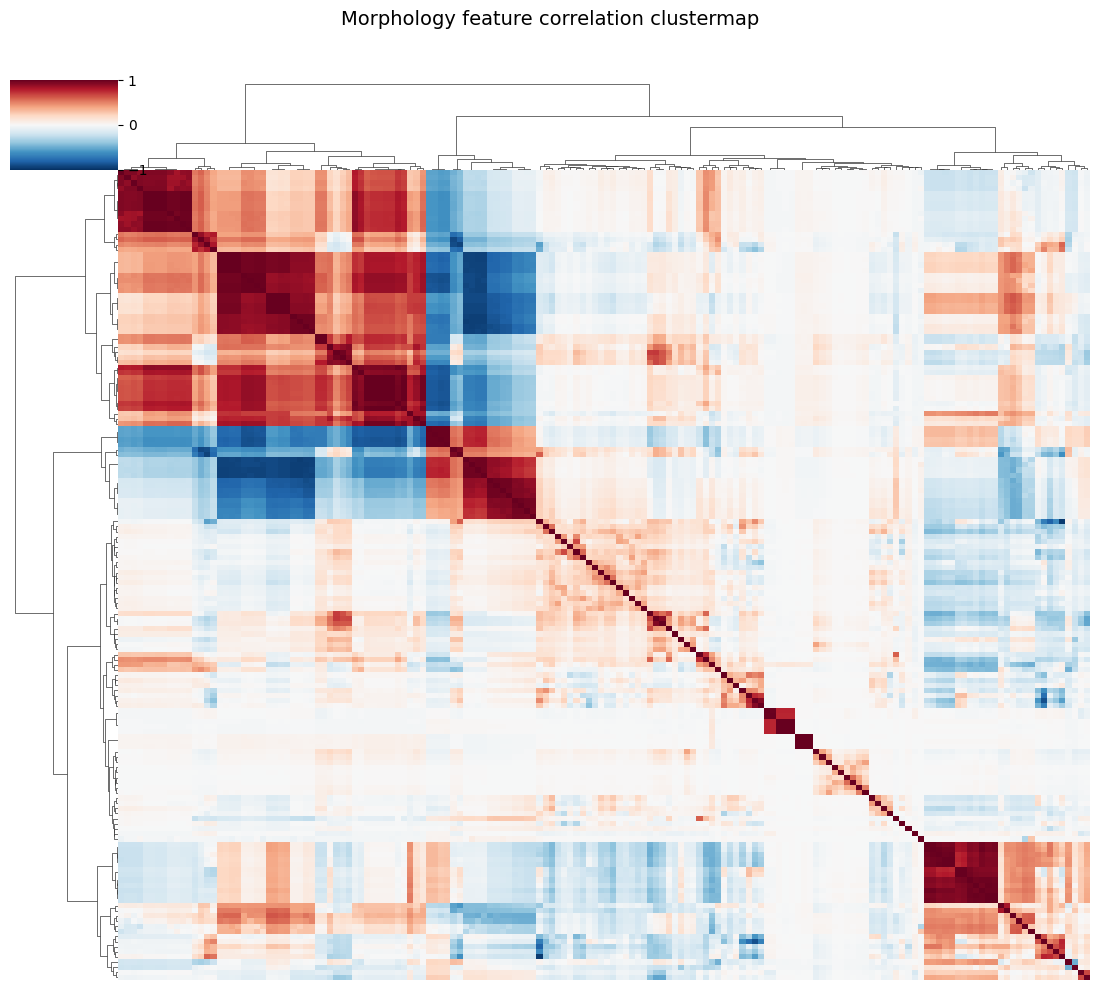

Feature pairs with |correlation| > 0.9: 330


In [ ]:
# Compute pairwise Pearson correlation matrix for all morphology features
corr_matrix = mitocheck_df.select(morph_cols).to_pandas().corr()

# Clustermap: hierarchical clustering (Ward linkage) groups correlated features together,
# making blocks of high correlation easy to spot visually.
# cbar_pos=(left, bottom, width, height) — width/height set to 1/4 of original
g = sns.clustermap(
    corr_matrix,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    figsize=(12, 10),
    xticklabels=False,
    yticklabels=False,
    dendrogram_ratio=(0.1, 0.1),
    cbar_pos=(0.02, 0.8, 0.008, 0.04),
    method="ward",
    metric="euclidean",
)

# Place the title at the very top of the figure (not on the heatmap axes)
g.fig.suptitle("Morphology feature correlation clustermap", fontsize=14, y=1.02)

# Adjust layout so the heatmap sits snugly against the dendrograms
g.fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

plt.savefig(
    plots_dir / "feature_correlation_clustermap.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

# Count feature pairs with |correlation| > 0.9 as a measure of redundancy
high_corr_pairs = [
    (f1, f2, corr_matrix.loc[f1, f2])
    for f1, f2 in itertools.combinations(morph_cols, 2)
    if abs(corr_matrix.loc[f1, f2]) > 0.9
]
print(f"Feature pairs with |correlation| > 0.9: {len(high_corr_pairs)}")